# 11 · Risk summary

Combine earlier results with a CAS premium-and-reserve scenario, parameter bootstrap and model-sensitivity comparison. Motor results are EUR per policy-year; CAS results are USD millions; the regulatory illustration is EUR millions.

VaR and ES measure losses. K = VaR − E[loss] is an internal capital proxy. Only the CAS premium and reserve blocks are combined, under the assumptions below.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from dataclasses import replace

from portfolio_model import LINES, LineFit, MultiLineResults, load_and_clean_line, marginal_from_fit, MIN_PREMIUM
from risk_measures import var, es
from dependence_model import valid_correlation, latent_from_spearman, spearman_matrix
from reinsurance_model import quota_share, aggregate_xol
from integration_model import integrated_losses, risk_row, reserve_lognormal
from insurance_model import CalibratedModel, clean_frequency, fit_severity, severity_mean, simulate_aggregate_losses
import parameter_risk as pr

names = ['calibrated_model.json', 'loss_summary.json', 'reinsurance_results.json', 'multi_line_results.json',
         'marginal_robustness.json', 'dependency_results.json', 'portfolio_reinsurance.json', 'pricing_results.json',
         'reserving_results.json', 'reserve_risk_summary.json', 'scr_results.json']
require_results(*names)
R = {name: json.loads(result_path(name).read_text()) for name in names}

M = 1000.0                                   # CAS data are USD thousands; shown in USD millions
nb05 = MultiLineResults.from_json(result_path('multi_line_results.json'))
fits = {l: LineFit(**nb05.fits[l]) for l in LINES}
marginals = {l: marginal_from_fit(fits[l]) for l in LINES}
latent = np.array(R['dependency_results.json']['latent_correlation_gaussian'])
N_SIM = nb05.n_sim
model = CalibratedModel.from_json(result_path('calibrated_model.json'))
print(f"Loaded results from 01-10. CAS simulations use {N_SIM:,} draws.")

Loaded results from 01-10. CAS simulations use 500,000 draws.


## Premium and reserve risk in one loss distribution (CAS, USD)

L_total = L_premium + L_reserve, per line and in total.

- L_premium is the simulated company-year ultimate loss from 05 and 06 (loss-ratio marginal × book premium, Gaussian copula across lines).
- L_reserve is the deviation of the unpaid reserve from its best estimate: a lognormal moment-matched to the Mack mean and standard error (09), minus the mean. The lognormal shape is an extra approximation. The best estimate is reserve-to-premium ratio × book premium, per line.
- Reserve deviations use the same cross-line latent correlation as premium risk. This correlation is assumed, not estimated.
- Premium and reserve risk of the same line are linked by a latent Gaussian correlation ρ_PR, applied as ρ_PR × the cross-line correlation. No reliable estimate of ρ_PR exists here, so three scenarios are shown: independent (0), moderate (0.25) and stressed (0.50). The stressed value is illustrative, not a regulatory calibration.
- The reserve deviation has mean zero, so expected loss is the premium-block expected loss, and K = VaR − EL.

This is an internal economic aggregation. It is not the Standard Formula aggregation in 10, which uses fixed sigma factors and prescribed correlations over a one-year horizon. Reserve risk here is runoff uncertainty (09); no one-year comparison is estimated.

In [2]:
per_line_reserve = pd.DataFrame(R['reserve_risk_summary.json']['per_line']).set_index('line').loc[LINES]
reserve_be = {l: float(per_line_reserve.loc[l, 'reserve_to_premium'] * fits[l].book_premium) for l in LINES}
reserve_cv = {l: float(per_line_reserve.loc[l, 'cv']) for l in LINES}
inputs = pd.DataFrame({'book_premium_usd_m': [fits[l].book_premium / M for l in LINES],
                       'reserve_to_premium': per_line_reserve['reserve_to_premium'].to_numpy(),
                       'reserve_best_estimate_usd_m': [reserve_be[l] / M for l in LINES],
                       'mack_cv': per_line_reserve['cv'].to_numpy(),
                       'negative_paid_increments': per_line_reserve['negative_paid_increments'].to_numpy()}, index=LINES)
display(inputs.round(3))
print("medmal, othliab and prodliab reserves come from long-tail paid triangles cut at lag 10 with negative increments, "
      "so their best estimates and CVs are probably understated.")

,book_premium_usd_m,reserve_to_premium,reserve_best_estimate_usd_m,mack_cv,negative_paid_increments
ppauto,11.786,0.776,9.141,0.020,0
comauto,5.618,0.951,5.343,0.037,0
wkcomp,11.395,0.923,10.517,0.031,0
othliab,4.063,1.406,5.713,0.085,1
medmal,4.828,1.615,7.797,0.257,1
prodliab,3.668,1.218,4.467,0.280,2


medmal, othliab and prodliab reserves come from long-tail paid triangles cut at lag 10 with negative increments, so their best estimates and CVs are probably understated.


In [3]:
RHO_SCENARIOS = {'Independent (rho_PR = 0)': 0.0, 'Moderate (rho_PR = 0.25)': 0.25, 'Stressed (rho_PR = 0.50)': 0.50}
sims = {name: integrated_losses(marginals, reserve_be, reserve_cv, latent, rho, N_SIM) for name, rho in RHO_SCENARIOS.items()}

rows = []
for name, s in sims.items():
    prem = risk_row(s['premium_total']); res = risk_row(s['reserve_total']); tot = risk_row(s['total'])
    rows.append(dict(scenario=name, EL=tot['EL'] / M, VaR_premium=prem['VaR'] / M, VaR_reserve_standalone=res['VaR'] / M,
                     VaR_total=tot['VaR'] / M, ES_total=tot['ES'] / M, K_premium=prem['K'] / M, K_total=tot['K'] / M,
                     reserve_added_to_K=(tot['K'] - prem['K']) / M, corr_prem_res=np.corrcoef(s['premium_total'], s['reserve_total'])[0, 1]))
integrated_table = pd.DataFrame(rows)
print('USD millions, gross of reinsurance')
display(integrated_table.round(3))

np.testing.assert_allclose(integrated_table['VaR_premium'].iloc[0] * M, R['dependency_results.json']['portfolio_var995_gaussian'] * M, rtol=1e-9)
assert integrated_table['VaR_total'].is_monotonic_increasing

USD millions, gross of reinsurance


,scenario,EL,VaR_premium,VaR_reserve_standalone,VaR_total,ES_total,K_premium,K_total,reserve_added_to_K,corr_prem_res
0,Independent (rho_PR = 0),28.295,62.202,7.685,62.455,82.910,33.911,34.161,0.250,-0.002
1,Moderate (rho_PR = 0.25),28.296,62.202,7.727,63.199,83.474,33.911,34.903,0.992,0.120
2,Stressed (rho_PR = 0.50),28.297,62.202,7.720,63.928,84.100,33.911,35.630,1.719,0.245


Premium-only VaR matches the Gaussian-copula baseline in 06. The table reports the reserve block's contribution to K under each assumed premium–reserve correlation.

### Net of reinsurance

Apply the 25% quota share and per-line stop-loss from 06 to the premium block. No additional treaty is applied to prior-year reserve deviations. The underlying CAS data are already net of historical reinsurance.

In [4]:
treaties = {
    'Quota share 25%': lambda l, L: quota_share(L, 0.25),
    'Stop-loss 200% xs 100% premium': lambda l, L: aggregate_xol(L, attachment=fits[l].book_premium, limit=2 * fits[l].book_premium),
}
net_rows = []
for name, s in sims.items():
    gross = risk_row(s['total'])
    net_rows.append(dict(scenario=name, treaty='Gross', EL=gross['EL'] / M, VaR=gross['VaR'] / M, ES=gross['ES'] / M, K=gross['K'] / M,
                         VaR_relief=0.0, ES_relief=0.0, expected_ceded=0.0))
    for tname, treaty in treaties.items():
        net_prem = np.zeros(N_SIM); ceded = 0.0
        for l in LINES:
            n_l, c_l = treaty(l, s['premium'][l])
            np.testing.assert_allclose(n_l + c_l, s['premium'][l], rtol=1e-12, atol=1e-8)
            net_prem += n_l; ceded += float(c_l.mean())
        net_total = net_prem + s['reserve_total']
        r = risk_row(net_total)
        net_rows.append(dict(scenario=name, treaty=tname, EL=r['EL'] / M, VaR=r['VaR'] / M, ES=r['ES'] / M, K=r['K'] / M,
                             VaR_relief=(gross['VaR'] - r['VaR']) / M, ES_relief=(gross['ES'] - r['ES']) / M, expected_ceded=ceded / M))
integrated_net = pd.DataFrame(net_rows)
print('USD millions; retained losses before reinsurance premium, so K is on a net-loss basis and ignores the cost of cover')
display(integrated_net.round(3))

USD millions; retained losses before reinsurance premium, so K is on a net-loss basis and ignores the cost of cover


,scenario,treaty,EL,VaR,ES,K,VaR_relief,ES_relief,expected_ceded
0,Independent (rho_PR = 0),Gross,28.295,62.455,82.910,34.161,0.000,0.000,0.000
1,Independent (rho_PR = 0),Quota share 25%,21.222,47.088,62.322,25.866,15.368,20.588,7.073
2,Independent (rho_PR = 0),Stop-loss 200% xs 100% premium,26.088,42.110,59.588,16.022,20.345,23.322,2.207
3,Moderate (rho_PR = 0.25),Gross,28.296,63.199,83.474,34.903,0.000,0.000,0.000
4,Moderate (rho_PR = 0.25),Quota share 25%,21.223,47.792,62.900,26.569,15.407,20.573,7.073
5,Moderate (rho_PR = 0.25),Stop-loss 200% xs 100% premium,26.089,43.034,60.327,16.945,20.165,23.147,2.207
6,Stressed (rho_PR = 0.50),Gross,28.297,63.928,84.100,35.630,0.000,0.000,0.000
7,Stressed (rho_PR = 0.50),Quota share 25%,21.225,48.555,63.546,27.331,15.372,20.554,7.073
8,Stressed (rho_PR = 0.50),Stop-loss 200% xs 100% premium,26.091,44.017,61.112,17.927,19.910,22.988,2.207


## Capital decomposition

Use the moderate premium–reserve scenario and 25% quota share. Each step is a difference in K from the same draws. Shuffling line columns creates an independence reference while preserving marginal samples. Steps reconcile to integrated net K; their attribution depends on the chosen order. Amounts are USD millions.

,step,value_usd_m,kind
0,Sum of stand-alone premium K,67.760,total
1,Cross-line diversification (lines independent),-36.099,delta
2,Fitted cross-line dependence,2.250,delta
3,Reserve risk (stand-alone sum),14.243,delta
4,Reserve cross-line diversification,-6.520,delta
5,Premium-reserve diversification,-6.731,delta
6,Integrated gross K,34.903,total
7,Quota share 25% (premium block),-8.334,delta
8,Integrated net K,26.569,total


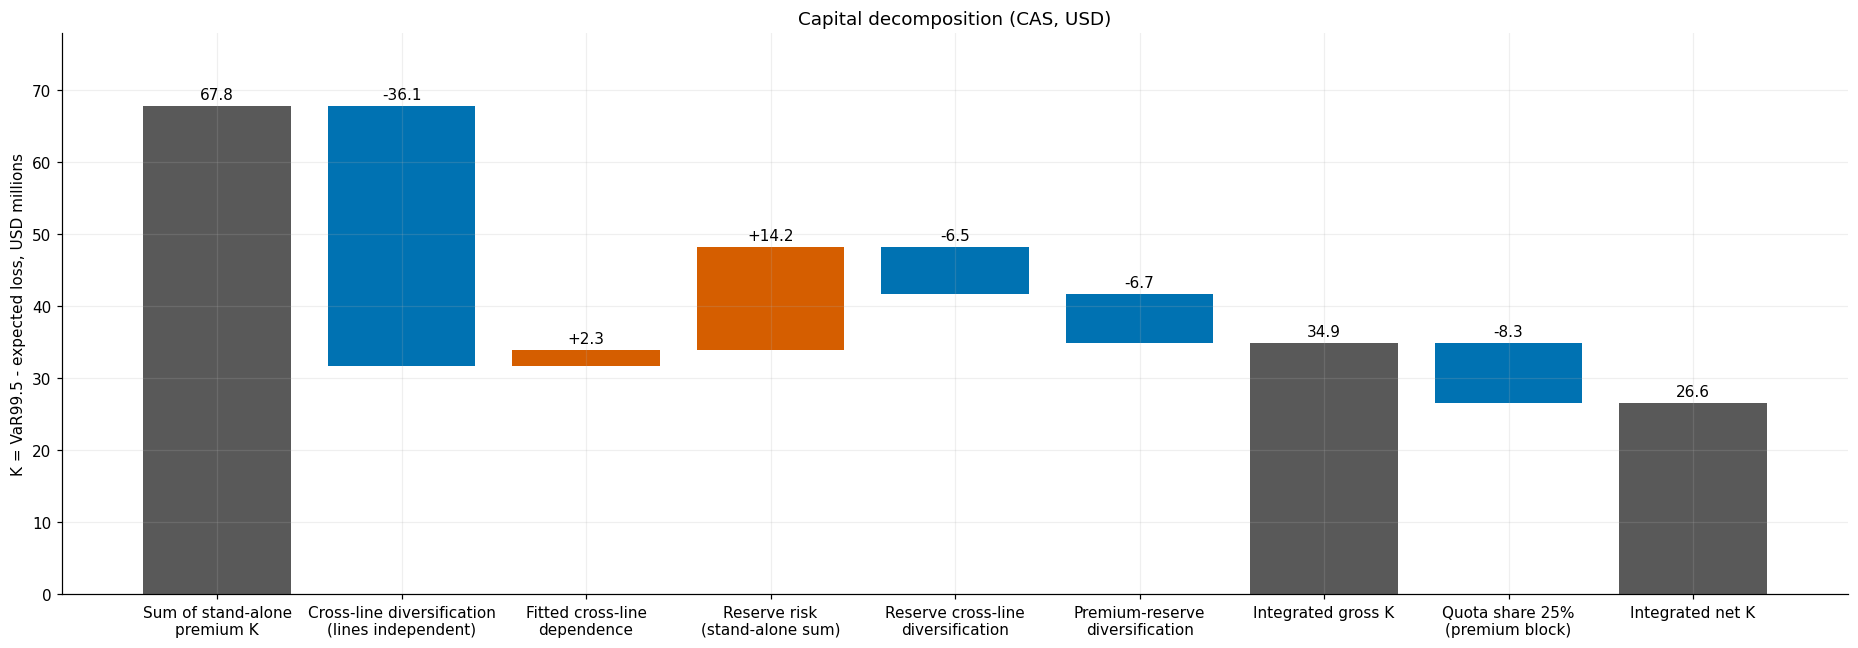

In [5]:
ref = 'Moderate (rho_PR = 0.25)'
s = sims[ref]
K = lambda x: float(var(x, 0.995) - np.mean(x))
A = sum(K(s['premium'][l]) for l in LINES)                       # stand-alone premium K, summed over lines
B = sum(K(s['reserve'][l]) for l in LINES)                       # stand-alone reserve K, summed over lines
rng_shuffle = np.random.default_rng(7)
shuffled_total = sum(rng_shuffle.permutation(s['premium'][l]) for l in LINES)
K_indep = K(shuffled_total)
K_prem = K(s['premium_total']); K_res = K(s['reserve_total']); K_tot = K(s['total'])
qs_net_prem = sum(quota_share(s['premium'][l], 0.25)[0] for l in LINES)
K_net = K(qs_net_prem + s['reserve_total'])

steps = [('Sum of stand-alone\npremium K', A, 'total'),
         ('Cross-line diversification\n(lines independent)', K_indep - A, 'delta'),
         ('Fitted cross-line\ndependence', K_prem - K_indep, 'delta'),
         ('Reserve risk\n(stand-alone sum)', B, 'delta'),
         ('Reserve cross-line\ndiversification', K_res - B, 'delta'),
         ('Premium-reserve\ndiversification', K_tot - K_prem - K_res, 'delta'),
         ('Integrated gross K', K_tot, 'total'),
         ('Quota share 25%\n(premium block)', K_net - K_tot, 'delta'),
         ('Integrated net K', K_net, 'total')]
waterfall = pd.DataFrame([dict(step=n.replace('\n', ' '), value_usd_m=v / M, kind=k) for n, v, k in steps])
running = waterfall.loc[waterfall.kind == 'total', 'value_usd_m'].iloc[0]
for i in range(1, len(waterfall)):
    if waterfall.kind[i] == 'delta':
        running += waterfall.value_usd_m[i]
    else:
        np.testing.assert_allclose(running, waterfall.value_usd_m[i], rtol=1e-9)
display(waterfall.round(3))

fig, ax = plt.subplots(figsize=(17, 6))
level = 0.0
for i, (name, v, kind) in enumerate(steps):
    v = v / M
    if kind == 'total':
        ax.bar(i, v, color='0.35'); level = v
        ax.text(i, v + 1, f'{v:,.1f}', ha='center')
    else:
        ax.bar(i, v, bottom=level, color='C3' if v > 0 else 'C0')
        ax.text(i, max(level, level + v) + 1, f'{v:+,.1f}', ha='center')
        level += v
ax.set_xticks(range(len(steps))); ax.set_xticklabels([s_[0] for s_ in steps])
ax.set_ylabel('K = VaR99.5 - expected loss, USD millions')
ax.set_title('Capital decomposition (CAS, USD)')
bar_top = max(max(patch.get_y(), patch.get_y() + patch.get_height()) for patch in ax.patches)
ax.set_ylim(0, bar_top * 1.15)
plt.tight_layout(); plt.show()

## Parameter risk

Separate repeated simulations with fixed parameters from refits to resampled data. Alternative marginal families, copulas and thresholds are compared in the next section.

For CAS, resample company-years within each line and refit Burr XII. Resample matched observations for the Spearman matrix. Common random numbers reduce simulation differences but do not eliminate finite-sample error. Marginal families, book premiums and Mack CVs are fixed; resampling does not preserve within-company dependence across years.

For motor, draw frequency parameters from the NB2 asymptotic normal approximation and refit severity to resampled claims. Each run uses fresh simulation draws. The reported variance subtraction is an approximation; heavy-tail ES remains unstable.

In [6]:
N_BOOT = 300
N_SIM_B = 100_000          # CAS draws per bootstrap replicate
RHO_REF = 0.25
base_corr = latent

base_100k = pr._cas_metrics(marginals, reserve_be, reserve_cv, base_corr, RHO_REF, N_SIM_B, 42, 43)
mc_cas = pr.cas_mc_replicates(marginals, reserve_be, reserve_cv, base_corr, RHO_REF, N_SIM_B, n_rep=40)

cred = {}; panels = {}
for l in LINES:
    c, _ = load_and_clean_line(l, data_dir=DATA_DIR, min_premium=MIN_PREMIUM)
    cred[l] = c
    panels[l] = c[['GRCODE', 'AccidentYear', 'LossRatio']].rename(columns={'LossRatio': l})

cas_variants = {'WC marginal only': 'wkcomp_marginal', 'All six marginals': 'all_marginals',
                'Dependence only': 'dependence', 'Marginals and dependence': 'marginals_and_dependence'}
cas_boot = {label: pr.cas_bootstrap(cred, fits, panels, base_corr, reserve_be, reserve_cv, RHO_REF, N_SIM_B, N_BOOT, v, seed=500)
            for label, v in cas_variants.items()}
print(f"CAS bootstrap done: {N_BOOT} replicates x {len(cas_variants)} variants, {N_SIM_B:,} draws each, reference premium-reserve rho = {RHO_REF}")

CAS bootstrap done: 300 replicates x 4 variants, 100,000 draws each, reference premium-reserve rho = 0.25


In [7]:
def summarise(series_dict, scale):
    rows = []
    for label, x in series_dict.items():
        x = np.asarray(x, dtype=float); x = x[np.isfinite(x)]
        iv = pr.interval(x)
        rows.append(dict(source=label, n=len(x), p05=iv['p_lo'] / scale, median=iv['median'] / scale, p95=iv['p_hi'] / scale, sd=iv['sd'] / scale))
    return pd.DataFrame(rows)

cas_var = {'Monte Carlo noise only': mc_cas['VaR_integrated']}
cas_var.update({f'Parameters: {k}': v['VaR_integrated'] for k, v in cas_boot.items()})
cas_summary = summarise(cas_var, M)
mc_sd = cas_summary.loc[0, 'sd']
cas_summary['parameter_sd_ex_mc'] = [np.nan] + [pr.parameter_sd(sd, 0.0) for sd in cas_summary['sd'][1:]]   # CRN draws carry no MC noise
cas_summary['width_p95_p05_pct_of_base'] = 100 * (cas_summary['p95'] - cas_summary['p05']) / (base_100k['VaR_integrated'] / M)
print(f"Integrated VaR99.5, USD millions. Baseline with the same {N_SIM_B:,} draws as the bootstrap: {base_100k['VaR_integrated']/M:,.2f}; "
      f"baseline with {N_SIM:,} draws: {risk_row(sims[ref]['total'])['VaR']/M:,.2f}")
display(cas_summary.round(3))

es_summary = summarise({'ES (premium block), Monte Carlo only': mc_cas['ES_premium'],
                        'ES (premium block), marginals and dependence': cas_boot['Marginals and dependence']['ES_premium']}, M)
display(es_summary.round(2))

Integrated VaR99.5, USD millions. Baseline with the same 100,000 draws as the bootstrap: 63.94; baseline with 500,000 draws: 63.20


,source,n,p05,median,p95,sd,parameter_sd_ex_mc,width_p95_p05_pct_of_base
0,Monte Carlo noise only,40,62.767,63.440,64.235,0.506,NaN,2.295
1,Parameters: WC marginal only,300,56.177,64.086,77.006,6.165,6.165,32.576
2,Parameters: All six marginals,300,56.305,64.195,74.895,5.856,5.856,29.073
3,Parameters: Dependence only,300,63.106,63.939,64.726,0.460,0.460,2.534
4,Parameters: Marginals and dependence,300,56.343,64.120,75.411,6.255,6.255,29.821


,source,n,p05,median,p95,sd
0,"ES (premium block), Monte Carlo only",40,79.700,82.460,86.530,2.350
1,"ES (premium block), marginals and dependence",300,68.020,87.900,128.380,19.890


CAS VaR varies more across refits than across fixed-parameter simulations. Workers' compensation accounts for most of the parameter spread. ES intervals are wider and sensitive to the observed tail; the bootstrap cannot establish uncertainty beyond the data and model assumptions.

In [8]:
N_SIM_M = 500_000
N_BOOT_M = 300
raw_freq = pd.read_csv(str(DATA_DIR / 'freMTPL2freq.csv'))
freq_clean, _ = clean_frequency(raw_freq)
sev_amounts = pd.read_csv(str(DATA_DIR / 'freMTPL2sev.csv'))['ClaimAmount'].to_numpy()
freq_fit = SimpleNamespace(lambda_nb=model.lambda_freq, r_nb=model.r_freq)

mc_motor = pr.motor_mc_replicates(model, N_SIM_M, n_rep=60)
motor_variants = {'Frequency only': 'frequency', 'Severity incl. GPD tail and threshold': 'severity',
                  'Frequency and severity': 'frequency_and_severity'}
motor_boot = {label: pr.motor_bootstrap(model, freq_clean, freq_fit, sev_amounts, N_SIM_M, N_BOOT_M, v, seed=700)
              for label, v in motor_variants.items()}

base_motor = R['loss_summary.json']
motor_var = {'Monte Carlo noise only': mc_motor['VaR']}
motor_var.update({f'Parameters: {k}': v['VaR'] for k, v in motor_boot.items()})
motor_summary = summarise(motor_var, 1.0)
motor_summary['parameter_sd_ex_mc'] = [np.nan] + [pr.parameter_sd(sd, motor_summary.loc[0, 'sd']) for sd in motor_summary['sd'][1:]]
print(f"Motor VaR99.5, EUR per policy-year. Baseline (seed 42, 500k): {base_motor['var_995']:,.0f}")
display(motor_summary.round(1))

both = motor_boot['Frequency and severity']
es_motor = summarise({'ES, Monte Carlo only': mc_motor['ES'], 'ES, frequency and severity parameters': both['ES']}, 1.0)
display(es_motor.round(0))
n_inf = int(both['infinite_mean'].sum())
print(f"GPD shape xi: fitted {model.xi_gpd:.3f}; bootstrap 5-95% = {both['xi'].quantile(.05):.3f} to {both['xi'].quantile(.95):.3f}; "
      f"{n_inf} of {len(both)} draws have xi >= 1 (infinite severity mean), where K is undefined.")

Motor VaR99.5, EUR per policy-year. Baseline (seed 42, 500k): 6,247


,source,n,p05,median,p95,sd,parameter_sd_ex_mc
0,Monte Carlo noise only,60,"6,115.800","6,261.000","6,380.700",84.500,NaN
1,Parameters: Frequency only,300,"6,137.600","6,263.400","6,385.200",77.800,0.000
2,Parameters: Severity incl. GPD tail and threshold,300,"6,062.900","6,257.500","6,403.900",98.900,51.400
3,Parameters: Frequency and severity,300,"6,078.800","6,259.900","6,425.600",106.200,64.300


,source,n,p05,median,p95,sd
0,"ES, Monte Carlo only",60,"21,404.000","26,340.000","49,490.000","36,255.000"
1,"ES, frequency and severity parameters",300,"20,055.000","25,881.000","56,260.000","53,421.000"


GPD shape xi: fitted 0.852; bootstrap 5-95% = 0.663 to 1.018; 20 of 300 draws have xi >= 1 (infinite severity mean), where K is undefined.


Motor VaR parameter spread is small relative to simulation noise, about 1% of VaR. ES is less stable: the fitted severity has infinite variance, and some resampled shapes reach ξ ≥ 1, implying an infinite mean. The ES intervals mix simulation and parameter effects and do not bound total uncertainty.

## Model sensitivity

Rows report changes in VaR and ES for each case. Motor amounts are EUR per policy-year; CAS amounts are USD millions. Percentage changes aid comparison but refer to different baselines. Rank by the larger absolute VaR or ES effect. Reinsurance decisions are shown without a rank.

In [9]:
dep = R['dependency_results.json']
grid = pd.DataFrame(dep['marginal_vs_dependence']['grid'])
scen = pd.DataFrame(dep['copula_scenarios']).set_index('scenario')
stress = pd.DataFrame(dep['correlation_stress']).set_index('alpha')
def g(wc, d, col='VaR995'):
    return float(grid.loc[(grid.wkcomp_marginal == wc) & (grid.dependence == d), col].iloc[0])
base_cas = g('Burr XII (baseline)', 'Gaussian copula'); base_cas_es = g('Burr XII (baseline)', 'Gaussian copula', 'ES995')

# motor: tail threshold and tail shape on the same seed and draws as 02 (single seed, so ES carries Monte Carlo noise)
def motor_case(m):
    x = simulate_aggregate_losses(500_000, m, np.random.default_rng(42))
    sev_mean = severity_mean(m)                      # infinite when the fitted GPD shape is at least 1
    return var(x, 0.995), es(x, 0.995), (m.lambda_freq * sev_mean if np.isfinite(sev_mean) else np.nan)
def with_threshold(pct):
    sf = fit_severity(sev_amounts, threshold_pct=pct)
    return replace(model, threshold=sf.threshold, alpha=sf.alpha, mu_body=sf.mu_body, sigma_body=sf.sigma_body,
                   xi_gpd=sf.xi_gpd, sigma_gpd=sf.sigma_gpd), sf
evt_rows = []
for pct in (97.5, 98.0, 98.5, 99.0, 99.5):
    m, sf = with_threshold(pct)
    v, e, mean = motor_case(m)
    evt_rows.append(dict(case=f'threshold {pct}th pct', threshold_eur=sf.threshold, exceedances=sf.n_tail, xi=sf.xi_gpd,
                         expected_loss=mean, VaR995=v, ES995=e, K=v - mean))
v, e, mean = motor_case(replace(model, xi_gpd=0.95))
evt_rows.append(dict(case='xi = 0.95 (other parameters as fitted)', threshold_eur=model.threshold, exceedances=np.nan, xi=0.95,
                     expected_loss=mean, VaR995=v, ES995=e, K=v - mean))
evt_detail = pd.DataFrame(evt_rows)
display(evt_detail.round(2))
base_evt = evt_detail.loc[evt_detail.case == 'threshold 99.0th pct'].iloc[0]
np.testing.assert_allclose(base_evt.VaR995, base_motor['var_995'], rtol=1e-9)
np.testing.assert_allclose(base_evt.ES995, base_motor['es_995'], rtol=1e-9)
evt_at = lambda case: evt_detail.loc[evt_detail.case == case].iloc[0]
es_rep = R['loss_summary.json']['es_995_replicates_500k']
es_range = f"{es_rep['p05']:,.0f} to {es_rep['p95']:,.0f}"

# integrated alternatives on the same draws as the reference scenario
be_bf = dict(reserve_be)
for l in ('wkcomp', 'comauto'):
    ratio = R['reserving_results.json']['lines'][l]['BF_unpaid'] / R['reserving_results.json']['lines'][l]['CL_unpaid']
    be_bf[l] = reserve_be[l] * ratio
cv2 = {l: 2 * c for l, c in reserve_cv.items()}
ref_row = risk_row(sims[ref]['total'])
alt_bf = risk_row(integrated_losses(marginals, be_bf, reserve_cv, latent, RHO_REF, N_SIM)['total'])
alt_cv2 = risk_row(integrated_losses(marginals, reserve_be, cv2, latent, RHO_REF, N_SIM)['total'])
ind_row, str_row = integrated_table.iloc[0], integrated_table.iloc[2]
net_q = integrated_net.query("scenario == @ref and treaty == 'Quota share 25%'").iloc[0]
net_s = integrated_net.query("scenario == @ref and treaty == 'Stop-loss 200% xs 100% premium'").iloc[0]
bs = cas_boot['Marginals and dependence']
boot_all = bs['VaR_integrated'] / M
mb = motor_boot['Frequency and severity']

def row(kind, assumption, basis, base_spec, alt_spec, base, alt, unit, reading):
    # base and alt are (VaR99.5, ES99.5) pairs on the same basis and unit
    return dict(kind=kind, assumption=assumption, basis=basis, base_specification=base_spec, alternative=alt_spec, unit=unit,
                base_VaR995=base[0], alternative_VaR995=alt[0], impact=alt[0] - base[0], impact_pct=100 * (alt[0] / base[0] - 1),
                base_ES995=base[1], alternative_ES995=alt[1], es_impact_pct=100 * (alt[1] / base[1] - 1), interpretation=reading)

gauss = (base_cas, base_cas_es)
t5 = scen.loc['Student-t copula, dof=5 (Kendall -> latent)']
ref_pair = (ref_row['VaR'] / M, ref_row['ES'] / M)
rows = [
  row('model specification', 'WC marginal: family', 'CAS USD m', 'Burr XII, Gaussian copula', 'Lognormal', gauss,
      (g('Lognormal', 'Gaussian copula'), g('Lognormal', 'Gaussian copula', 'ES995')), 'USD m',
      'Lognormal has a fatter upper tail than Burr XII for wkcomp, so the AIC-preferred Burr is the less conservative fit.'),
  row('model specification', 'WC marginal: AY2001 inclusion', 'CAS USD m', 'Burr XII, all years', 'Burr XII, AY2001 excluded', gauss,
      (g('Burr XII, AY2001 excluded', 'Gaussian copula'), g('Burr XII, AY2001 excluded', 'Gaussian copula', 'ES995')), 'USD m',
      'AY2001 has unusually low premiums and high loss ratios; the cause is unresolved.'),
  row('model specification', 'WC marginal: empirical tail', 'CAS USD m', 'Burr XII', 'Empirical (all years)', gauss,
      (g('Empirical (all years)', 'Gaussian copula'), g('Empirical (all years)', 'Gaussian copula', 'ES995')), 'USD m',
      'The empirical tail rests on AY2001: all of the 12 largest wkcomp loss ratios are from that year. Not a stable estimate.'),
  row('model specification', 'Copula family', 'CAS USD m', 'Gaussian', 'Student-t, 5 dof', gauss, (t5.VaR995, t5.ES995), 'USD m',
      'Tail dependence raises the joint tail.'),
  row('model specification', 'Correlation stress', 'CAS USD m', 'Fitted correlation', 'alpha = 0.5 toward rho = 0.7',
      (float(stress.loc[0.0, 'VaR995']), float(stress.loc[0.0, 'ES995'])), (float(stress.loc[0.5, 'VaR995']), float(stress.loc[0.5, 'ES995'])),
      'USD m', 'The assumed correlation stress reduces diversification.'),
  row('model specification', 'Premium-reserve dependence', 'CAS USD m', 'rho_PR = 0', 'rho_PR = 0.50', (ind_row.VaR_total, ind_row.ES_total),
      (str_row.VaR_total, str_row.ES_total), 'USD m',
      'Reserve risk adds little in the tested dependence scenarios; large-line Mack CVs are small.'),
  row('model specification', 'Reserve volatility', 'CAS USD m', 'Mack CV, rho_PR = 0.25', 'Mack CV x 2', ref_pair,
      (alt_cv2['VaR'] / M, alt_cv2['ES'] / M), 'USD m', 'Doubling the reserve CV is a proxy for reserve model risk that Mack does not include.'),
  row('model specification', 'Reserve method', 'CAS USD m', 'Chain-Ladder best estimate', 'Bornhuetter-Ferguson (wkcomp, comauto)',
      ref_pair, (alt_bf['VaR'] / M, alt_bf['ES'] / M), 'USD m',
      'BF raises the wkcomp and comauto reserves by about 25% (balance sheet), but K barely moves because the deviation around the reserve is only a few percent.'),
  row('parameter uncertainty', 'Marginals and dependence', 'CAS USD m', 'Point estimate', 'Bootstrap 95th percentile',
      (base_100k['VaR_integrated'] / M, base_100k['ES_integrated'] / M),
      (float(np.percentile(bs['VaR_integrated'], 95)) / M, float(np.percentile(bs['ES_integrated'], 95)) / M), 'USD m',
      'Bootstrap spread with model families fixed and common random numbers.'),
  row('model specification', 'EVT threshold', 'Motor EUR', '99.0th percentile', '98.0th percentile',
      (base_evt.VaR995, base_evt.ES995), (evt_at('threshold 98.0th pct').VaR995, evt_at('threshold 98.0th pct').ES995), 'EUR per policy-year',
      f"xi = {evt_at('threshold 98.0th pct').xi:.2f}, so the fitted severity mean is infinite. VaR is almost unaffected because the 99.5% quantile lies below the threshold; ES moves because it is a tail mean. Single seed: the ES Monte Carlo range alone is {es_range}."),
  row('model specification', 'EVT threshold', 'Motor EUR', '99.0th percentile', '99.5th percentile',
      (base_evt.VaR995, base_evt.ES995), (evt_at('threshold 99.5th pct').VaR995, evt_at('threshold 99.5th pct').ES995), 'EUR per policy-year',
      f"Only about {int(evt_at('threshold 99.5th pct').exceedances)} exceedances above the threshold. Same Monte Carlo caveat for ES."),
  row('model specification', 'GPD shape', 'Motor EUR', f'xi = {model.xi_gpd:.3f}', 'xi = 0.95', (base_evt.VaR995, base_evt.ES995),
      (evt_at('xi = 0.95 (other parameters as fitted)').VaR995, evt_at('xi = 0.95 (other parameters as fitted)').ES995), 'EUR per policy-year',
      'VaR changes less than ES in this scenario. The mean is infinite for xi >= 1.'),
  row('parameter uncertainty', 'Frequency and severity', 'Motor EUR', 'Point estimate', 'Bootstrap 95th percentile',
      (base_evt.VaR995, base_evt.ES995), (float(np.percentile(mb['VaR'], 95)), float(np.percentile(mb['ES'], 95))), 'EUR per policy-year',
      'Includes Monte Carlo noise. ES is far less stable than VaR.'),
  row('management action', 'Reinsurance: quota share', 'CAS USD m', 'Gross, rho_PR = 0.25', 'Quota share 25%', ref_pair,
      (net_q.VaR, net_q.ES), 'USD m', 'Proportional relief; ignores the cost of cover. A decision, not a model uncertainty.'),
  row('management action', 'Reinsurance: stop-loss', 'CAS USD m', 'Gross, rho_PR = 0.25', 'Per-line stop-loss 200% xs 100%',
      ref_pair, (net_s.VaR, net_s.ES), 'USD m',
      'Larger relief than quota share, but reinsurance and diversification overlap: D_VaR falls from 35% to 17% in 06. A decision, not a model uncertainty.'),
]
model_risk = pd.DataFrame(rows)
model_risk['max_abs_impact_pct'] = model_risk[['impact_pct', 'es_impact_pct']].abs().max(axis=1)
is_assumption = model_risk.kind != 'management action'
model_risk['rank'] = np.nan
model_risk.loc[is_assumption, 'rank'] = model_risk.loc[is_assumption, 'max_abs_impact_pct'].rank(ascending=False)
show = model_risk.sort_values(['rank', 'kind'])[['rank', 'kind', 'assumption', 'basis', 'alternative', 'base_VaR995', 'alternative_VaR995',
                                                  'impact_pct', 'es_impact_pct', 'interpretation']]
pd.set_option('display.max_colwidth', 90)
display(show.round(1).reset_index(drop=True))
print(f"Motor ES effects are single-seed. ES 99.5% across 500k-draw replicates ranges {es_range} (5th-95th pct, "
      f"{100*(es_rep['p95']-es_rep['p05'])/es_rep['median']:.0f}% of the median) and the seed-42 value is {base_motor['es_995']:,.0f}, "
      f"so motor ES differences of that size cannot be told apart from Monte Carlo noise.")

,case,threshold_eur,exceedances,xi,expected_loss,VaR995,ES995,K
0,threshold 97.5th pct,"8,234.240",666.000,1.020,NaN,"6,057.200","47,898.540",NaN
1,threshold 98.0th pct,"9,889.700",533.000,1.160,NaN,"6,172.640","92,450.120",NaN
2,threshold 98.5th pct,"11,902.610",400.000,0.960,583.610,"6,184.140","51,787.840","5,600.530"
3,threshold 99.0th pct,"16,793.700",267.000,0.850,297.110,"6,247.400","45,791.510","5,950.280"
4,threshold 99.5th pct,"34,386.990",134.000,0.800,268.550,"6,207.620","36,193.200","5,939.070"
5,xi = 0.95 (other parameters as fitted),"16,793.700",NaN,0.950,534.540,"6,247.400","70,264.420","5,712.850"


,rank,kind,assumption,basis,alternative,base_VaR995,alternative_VaR995,impact_pct,es_impact_pct,interpretation
0,1.000,model specification,WC marginal: empirical tail,CAS USD m,Empirical (all years),62.200,137.200,120.500,650.600,The empirical tail rests on AY2001: all of the 12 largest wkcomp loss ratios are from ...
1,2.000,model specification,EVT threshold,Motor EUR,98.0th percentile,"6,247.400","6,172.600",-1.200,101.900,"xi = 1.16, so the fitted severity mean is infinite. VaR is almost unaffected because t..."
2,3.000,model specification,GPD shape,Motor EUR,xi = 0.95,"6,247.400","6,247.400",0.000,53.400,VaR changes less than ES in this scenario. The mean is infinite for xi >= 1.
3,4.000,parameter uncertainty,Marginals and dependence,CAS USD m,Bootstrap 95th percentile,63.900,75.400,17.900,43.500,Bootstrap spread with model families fixed and common random numbers.
4,5.000,model specification,WC marginal: AY2001 inclusion,CAS USD m,"Burr XII, AY2001 excluded",62.200,48.100,-22.600,-35.100,AY2001 has unusually low premiums and high loss ratios; the cause is unresolved.
5,6.000,parameter uncertainty,Frequency and severity,Motor EUR,Bootstrap 95th percentile,"6,247.400","6,425.600",2.900,22.900,Includes Monte Carlo noise. ES is far less stable than VaR.
6,7.000,model specification,EVT threshold,Motor EUR,99.5th percentile,"6,247.400","6,207.600",-0.600,-21.000,Only about 134 exceedances above the threshold. Same Monte Carlo caveat for ES.
7,8.000,model specification,WC marginal: family,CAS USD m,Lognormal,62.200,75.200,20.900,11.200,"Lognormal has a fatter upper tail than Burr XII for wkcomp, so the AIC-preferred Burr ..."
8,9.000,model specification,Correlation stress,CAS USD m,alpha = 0.5 toward rho = 0.7,62.200,72.900,17.200,14.800,The assumed correlation stress reduces diversification.
9,10.000,model specification,Copula family,CAS USD m,"Student-t, 5 dof",62.200,66.800,7.400,7.600,Tail dependence raises the joint tail.


Motor ES effects are single-seed. ES 99.5% across 500k-draw replicates ranges 21,111 to 40,162 (5th-95th pct, 71% of the median) and the seed-42 value is 45,792, so motor ES differences of that size cannot be told apart from Monte Carlo noise.


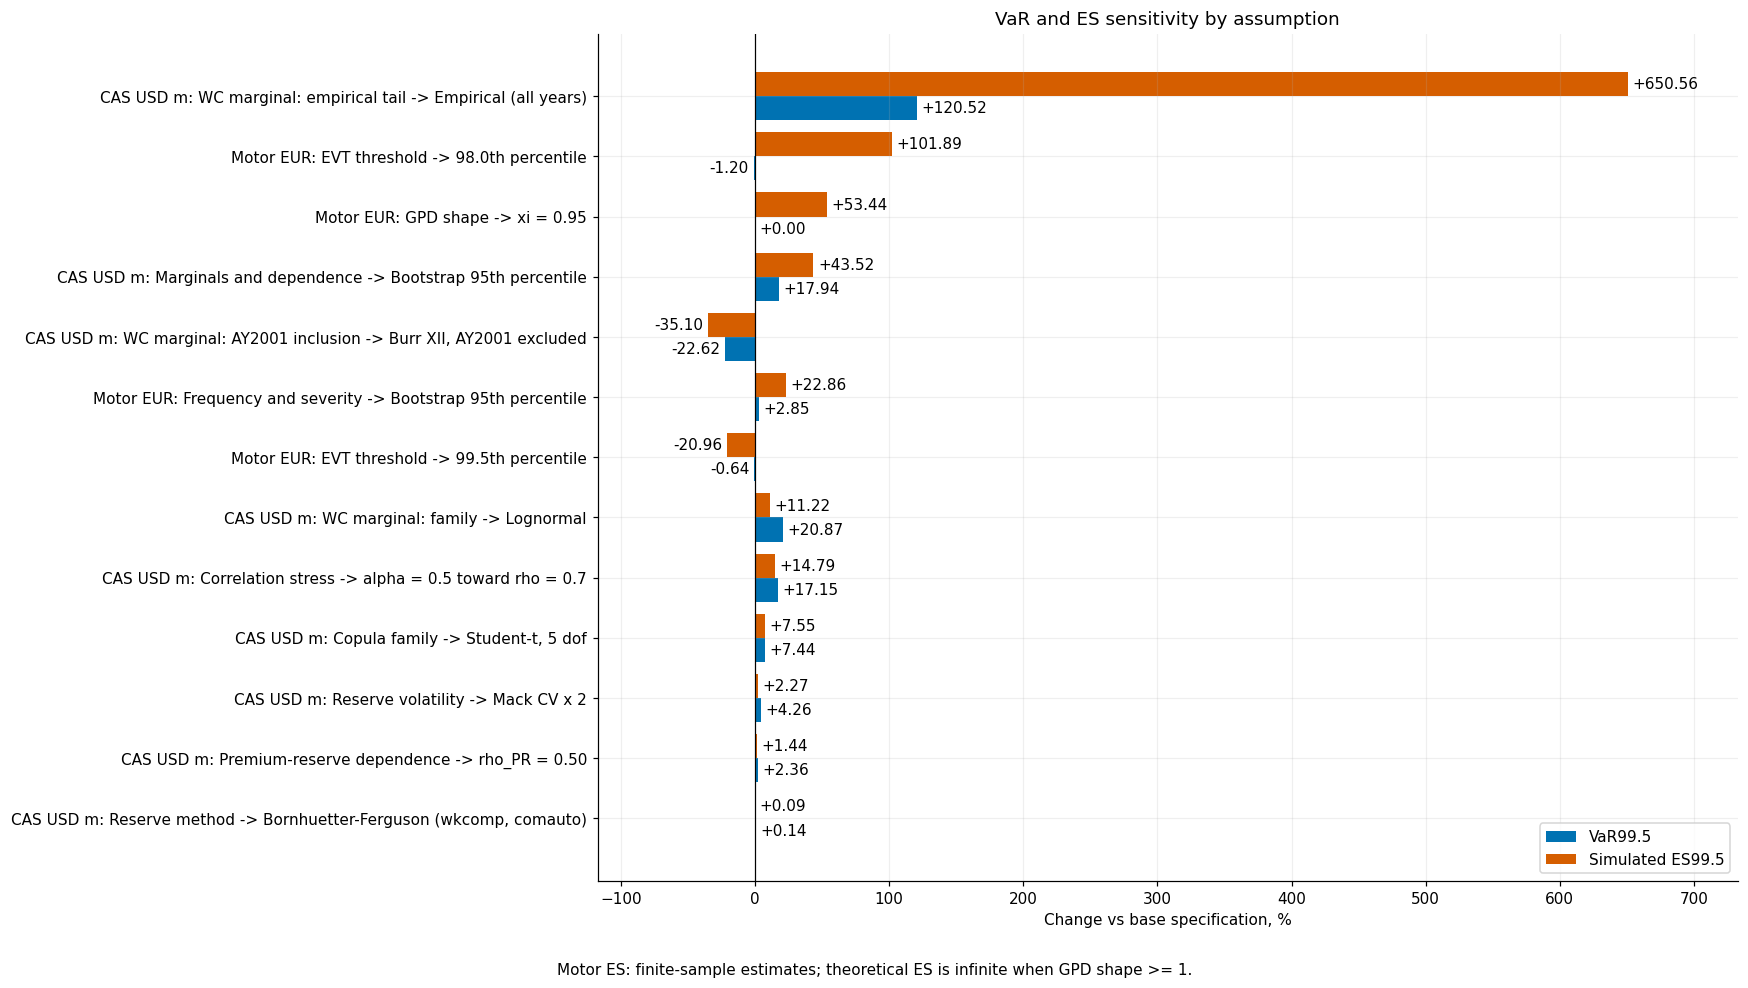

In [10]:
plot = model_risk[model_risk.kind != 'management action'].sort_values('max_abs_impact_pct')
fig, ax = plt.subplots(figsize=(16, 9))
y = np.arange(len(plot)); h = 0.4
var_bars = ax.barh(y - h/2, plot['impact_pct'], height=h, color='C0', label='VaR99.5')
es_bars = ax.barh(y + h/2, plot['es_impact_pct'], height=h, color='C3', label='Simulated ES99.5')
ax.set_yticks(y)
ax.set_yticklabels([f"{b}: {a} -> {c}" for a, b, c in zip(plot['assumption'], plot['basis'], plot['alternative'])])
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Change vs base specification, %')
ax.set_title('VaR and ES sensitivity by assumption')
ax.legend()
ax.bar_label(var_bars, fmt='%+.2f', padding=3)
ax.bar_label(es_bars, fmt='%+.2f', padding=3)
ax.margins(x=0.12)
fig.text(0.5, 0.01, 'Motor ES: finite-sample estimates; theoretical ES is infinite when GPD shape >= 1.', ha='center')
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

## Results tables

The tables below collect expected losses, tail risk, diversification, reinsurance, reserves, regulatory capital, allocation and model sensitivity from the saved results.

In [11]:
ls = R['loss_summary.json']
cas_ind = scen.loc['Independence benchmark (notebook 05)']; cas_gauss = scen.loc['Gaussian copula (Spearman -> latent)']
es_rep = ls['es_995_replicates_500k']
print('1. Expected loss')
display(pd.DataFrame([
    dict(basis='Motor, EUR per policy-year', item='Expected aggregate loss (analytical)', value=ls['analytical_mean_loss']),
    dict(basis='Motor, EUR per policy-year', item='Expected aggregate loss (simulated, seed 42)', value=ls['mean_loss']),
    dict(basis='CAS, USD m', item='Six-line expected loss (premium block)', value=nb05.portfolio_mean / M),
    dict(basis='CAS, USD m', item='Reserve best estimate, six lines', value=sum(reserve_be.values()) / M)]).round(2))

print('2. Tail risk')
display(pd.DataFrame([
    dict(basis='Motor EUR', item='VaR 99.5% / ES 99.5% / K', value=f"{ls['var_995']:,.0f} / {ls['es_995']:,.0f} / {ls['capital_proxy_995']:,.0f}"),
    dict(basis='Motor EUR', item='ES 99.5% across 500k replicates (5th-95th pct)', value=f"{es_rep['p05']:,.0f} to {es_rep['p95']:,.0f}"),
    dict(basis='CAS USD m', item='Independence: VaR / ES / K', value=f"{cas_ind.VaR995:,.1f} / {cas_ind.ES995:,.1f} / {cas_ind.K:,.1f}"),
    dict(basis='CAS USD m', item='Gaussian copula: VaR / ES / K', value=f"{cas_gauss.VaR995:,.1f} / {cas_gauss.ES995:,.1f} / {cas_gauss.K:,.1f}"),
    dict(basis='CAS USD m', item='Integrated with reserve (rho_PR 0.25): VaR / ES / K',
         value=f"{integrated_table.loc[1,'VaR_total']:,.1f} / {integrated_table.loc[1,'ES_total']:,.1f} / {integrated_table.loc[1,'K_total']:,.1f}")]))

print('3. Diversification (CAS, USD)')
display(pd.DataFrame({'D_VaR': [cas_ind.D_VaR, cas_gauss.D_VaR, scen.loc['Student-t copula, dof=5 (Kendall -> latent)'].D_VaR,
                                float(stress.loc[0.5, 'D_VaR']), 0.0],
                      'D_K': [cas_ind.D_K, cas_gauss.D_K, scen.loc['Student-t copula, dof=5 (Kendall -> latent)'].D_K,
                              float(stress.loc[0.5, 'D_K']), 0.0]},
                     index=['Independence', 'Gaussian (fitted)', 'Student-t, 5 dof', 'Stress alpha = 0.5', 'Comonotonic']).round(3))

print('4. Reinsurance (CAS, USD m, Gaussian copula, premium block)')
display(pd.DataFrame(R['portfolio_reinsurance.json']['results']).query("dependence == 'Gaussian copula'").round(2))
print('Motor EUR (02-04): see the stress table in 04; quota share and XoL there are single-line.')

print('5. Reserve uncertainty (CAS paid triangles, runoff, USD m)')
ru = R['reserve_risk_summary.json']
display(per_line_reserve.assign(reserve_usd_m=per_line_reserve.reserve / M, std_error_usd_m=per_line_reserve.std_error / M)
        [['reserve_usd_m', 'std_error_usd_m', 'cv', 'reserve_to_premium']].round(3))
print(f"wkcomp Chain-Ladder unpaid {R['reserving_results.json']['lines']['wkcomp']['CL_unpaid']/M:,.0f}m vs "
      f"Bornhuetter-Ferguson {R['reserving_results.json']['lines']['wkcomp']['BF_unpaid']/M:,.0f}m. Runoff, not one-year, risk.")

1. Expected loss


,basis,item,value
0,"Motor, EUR per policy-year",Expected aggregate loss (analytical),297.110
1,"Motor, EUR per policy-year","Expected aggregate loss (simulated, seed 42)",350.430
2,"CAS, USD m",Six-line expected loss (premium block),28.270
3,"CAS, USD m","Reserve best estimate, six lines",42.980


2. Tail risk


,basis,item,value
0,Motor EUR,VaR 99.5% / ES 99.5% / K,"6,247 / 45,792 / 5,950"
1,Motor EUR,ES 99.5% across 500k replicates (5th-95th pct),"21,111 to 40,162"
2,CAS USD m,Independence: VaR / ES / K,60.3 / 79.7 / 32.0
3,CAS USD m,Gaussian copula: VaR / ES / K,62.2 / 82.7 / 33.9
4,CAS USD m,Integrated with reserve (rho_PR 0.25): VaR / ES / K,63.2 / 83.5 / 34.9


3. Diversification (CAS, USD)


...

4. Reinsurance (CAS, USD m, Gaussian copula, premium block)


,dependence,treaty,VaR995,ES995,expected_ceded,VaR_relief,ES_relief,D_VaR,D_K
0,Gaussian copula,Gross,62.200,82.740,0.000,0.000,0.000,0.350,0.500
1,Gaussian copula,Quota share 25%,46.650,62.060,7.070,15.550,20.690,0.350,0.500
2,Gaussian copula,Stop-loss 200% xs 100% premium,40.010,58.890,2.210,22.200,23.850,0.170,0.360


Motor EUR (02-04): see the stress table in 04; quota share and XoL there are single-line.
5. Reserve uncertainty (CAS paid triangles, runoff, USD m)


,reserve_usd_m,std_error_usd_m,cv,reserve_to_premium
line,,,,
ppauto,"18,723.968",378.494,0.020,0.776
comauto,"2,064.727",75.432,0.037,0.951
wkcomp,"3,267.681",102.373,0.031,0.923
othliab,"2,906.068",247.106,0.085,1.406
medmal,847.716,217.922,0.257,1.615
prodliab,192.670,53.949,0.280,1.218


wkcomp Chain-Ladder unpaid 3,268m vs Bornhuetter-Ferguson 4,090m. Runoff, not one-year, risk.


In [12]:
reg = R['scr_results.json']
print('6. Regulatory capital (illustrative Standard Formula case, EUR million)')
print(f"{reg['name']}: EUR {reg['scr']:,.3f} million. Sensitivities: " + ', '.join(f"{k} {v:,.3f}" for k, v in reg['sensitivities'].items()))
print('Not a total SCR. Excludes catastrophe, lapse, other segments, market, default, operational risk and adjustments.')
display(pd.DataFrame(reg['segments']).round(3))

print('7. Capital allocation and illustrative RORAC (CAS, USD)')
attr = pd.DataFrame(dep['capital_attribution']).set_index('Line')
rorac = pd.DataFrame(dep['rorac']['table']).set_index('Line')[['premium', 'expected_profit', 'allocated_capital', 'RORAC']]
display(attr.join(rorac).round(3))
print(f"Illustrative RORAC assumes a {dep['rorac']['expense_ratio_assumed']:.0%} expense ratio and Euler ES allocation; it is not insurer profitability.")
pl = R['pricing_results.json']['capital_loading']
print(f"Pricing link (motor EUR): illustrative capital loading k = {pl['k']:.1%} gives {pl['sensitivity'][2]['loading_pct_of_pure_premium']:.0f}% of pure premium; "
      f"k = 0 to 2% moves the average gross premium from EUR {pl['sensitivity'][0]['avg_gross_premium_eur']:,.0f} to EUR {pl['sensitivity'][-1]['avg_gross_premium_eur']:,.0f}.")

print('8. Model sensitivity: largest VaR or ES effects')
display(show.dropna(subset=['rank']).head(6)[['rank', 'assumption', 'alternative', 'basis', 'impact_pct', 'es_impact_pct']].round(1).reset_index(drop=True))

6. Regulatory capital (illustrative Standard Formula case, EUR million)
Illustrative premium and reserve underwriting-risk SCR component (Standard Formula): EUR 83.346 million. Sensitivities: Baseline 83.346, Forward premiums +20% 88.127, Gross claims BE +20% 93.827
Not a total SCR. Excludes catastrophe, lapse, other segments, market, default, operational risk and adjustments.


,segment,premium_volume,reserve_volume,volume,premium_sigma,reserve_sigma,sigma,weighted_sigma,standalone_scr
0,1,123.000,75,198.000,0.080,0.090,0.073,14.450,43.351
1,5,72.000,110,182.000,0.112,0.110,0.097,17.579,52.736


7. Capital allocation and illustrative RORAC (CAS, USD)


,Premium share,Expected-loss share,Standalone VaR995 share,Allocated ES995 share (Euler),premium,expected_profit,allocated_capital,RORAC
Line,,,,,,,,
ppauto,0.285,0.279,0.150,0.115,11.786,0.352,1.607,0.219
comauto,0.136,0.117,0.082,0.059,5.618,0.610,1.559,0.391
wkcomp,0.276,0.299,0.404,0.691,11.395,-0.478,48.730,-0.010
othliab,0.098,0.082,0.094,0.035,4.063,0.515,0.528,0.975
medmal,0.117,0.149,0.173,0.071,4.828,-0.846,1.620,-0.523
prodliab,0.089,0.073,0.096,0.030,3.668,0.507,0.406,1.250


Illustrative RORAC assumes a 30% expense ratio and Euler ES allocation; it is not insurer profitability.
Pricing link (motor EUR): illustrative capital loading k = 1.0% gives 20% of pure premium; k = 0 to 2% moves the average gross premium from EUR 404 to EUR 550.
8. Model sensitivity: largest VaR or ES effects


,rank,assumption,alternative,basis,impact_pct,es_impact_pct
0,1.000,WC marginal: empirical tail,Empirical (all years),CAS USD m,120.500,650.600
1,2.000,EVT threshold,98.0th percentile,Motor EUR,-1.200,101.900
2,3.000,GPD shape,xi = 0.95,Motor EUR,0.000,53.400
3,4.000,Marginals and dependence,Bootstrap 95th percentile,CAS USD m,17.900,43.500
4,5.000,WC marginal: AY2001 inclusion,"Burr XII, AY2001 excluded",CAS USD m,-22.600,-35.100
5,6.000,Frequency and severity,Bootstrap 95th percentile,Motor EUR,2.900,22.900


In [13]:
ranked = model_risk.dropna(subset=['rank']).sort_values('rank')
top_cas = ranked[ranked.basis == 'CAS USD m'].head(3)
evt98 = model_risk[(model_risk.assumption == 'EVT threshold') & (model_risk.alternative == '98.0th percentile')].iloc[0]
print("Results")
print(f"- Cross-line VaR diversification is {cas_gauss.D_VaR:.0%} under the fitted Gaussian dependence and falls to {float(stress.loc[0.5,'D_VaR']):.0%} "
      f"when correlation is half-way stressed. Workers' comp alone takes {attr.loc['wkcomp', 'Allocated ES995 share (Euler)']:.0%} of allocated ES.")
print(f"- Reserve risk adds {integrated_table.loc[1,'reserve_added_to_K']:,.1f}m to K ({100*integrated_table.loc[1,'reserve_added_to_K']/integrated_table.loc[1,'K_premium']:.1f}% of premium-block K) "
      f"at rho_PR = 0.25, because Mack CVs are small for the large lines. This uses runoff reserve uncertainty; one-year risk is not estimated.")
print("- Largest effects among CAS assumptions (VaR / ES): " + '; '.join(f"{r.assumption}, {r.alternative} ({r.impact_pct:+.0f}% / {r.es_impact_pct:+.0f}%)" for r in top_cas.itertuples()) + '.')
print(f"- The bootstrap puts the 95th percentile of the CAS integrated VaR {100*(np.percentile(boot_all,95)/(base_100k['VaR_integrated']/M)-1):+.0f}% above the point estimate; "
      f"Monte Carlo noise is about {100*mc_sd/(base_100k['VaR_integrated']/M):.1f}% (one SD).")
print(f"- Motor: moving the EVT threshold to the 98th percentile changes VaR by {evt98.impact_pct:+.1f}% but ES by {evt98.es_impact_pct:+.0f}%. VaR is less sensitive than ES in this scenario.")
print("- ES is less stable than VaR in both cases and requires a range and stated assumptions.")

Results
- Cross-line VaR diversification is 35% under the fitted Gaussian dependence and falls to 24% when correlation is half-way stressed. Workers' comp alone takes 69% of allocated ES.
- Reserve risk adds 1.0m to K (2.9% of premium-block K) at rho_PR = 0.25, because Mack CVs are small for the large lines. This uses runoff reserve uncertainty; one-year risk is not estimated.
- Largest effects among CAS assumptions (VaR / ES): WC marginal: empirical tail, Empirical (all years) (+121% / +651%); Marginals and dependence, Bootstrap 95th percentile (+18% / +44%); WC marginal: AY2001 inclusion, Burr XII, AY2001 excluded (-23% / -35%).
- The bootstrap puts the 95th percentile of the CAS integrated VaR +18% above the point estimate; Monte Carlo noise is about 0.8% (one SD).
- Motor: moving the EVT threshold to the 98th percentile changes VaR by -1.2% but ES by +102%. VaR is less sensitive than ES in this scenario.
- ES is less stable than VaR in both cases and requires a range and stated ass

## Checks and limits

Checks cover result freshness, exposure units, held-out separation, treaty settlement, triangle conversion, package comparisons and regulatory arithmetic. Execution status is recorded in `results/validation/validation.json`.

- Motor, CAS and regulatory cases do not describe a common insurer.
- CAS premium and reserve blocks are combined only in an illustrative scenario, with assumed dependence and runoff reserve uncertainty.
- CAS loss-ratio observations are scaled company-year data. AY2001 strongly affects the workers' compensation tail; its cause is unresolved.
- The bootstrap fixes Mack CVs and model families. Copula and marginal alternatives are assessed separately.
- Motor severity has infinite variance; ES estimates are unstable.
- Complete-filing selection, overlapping backtests and the lag-10 cutoff limit reserve inference.

In [14]:
integrated_risk = dict(
    unit='USD millions', basis='CAS loss-ratio scenarios and runoff reserves; not one insurer',
    definition='L_total = L_premium + L_reserve; reserve deviation has mean zero; K = VaR99.5 - E[L]',
    premium_reserve_dependence='assumed latent Gaussian correlation scaled by the cross-line correlation; scenarios 0, 0.25, 0.50',
    reserve_inputs=inputs.reset_index(names='line').to_dict('records'),
    scenarios=integrated_table.to_dict('records'), net_of_reinsurance=integrated_net.to_dict('records'),
    waterfall=dict(reference_scenario=ref, treaty='Quota share 25% on premium block', steps=waterfall.to_dict('records')),
    note='Internal economic aggregation; not the Solvency II Standard Formula aggregation in notebook 10.')
json.dump(integrated_risk, open(result_path('integrated_risk.json'), 'w'), indent=2, default=float)

def records(df): return df.to_dict('records')
parameter_risk = dict(
    n_bootstrap=N_BOOT, cas=dict(unit='USD millions', reference_rho_pr=RHO_REF, n_draws_per_replicate=N_SIM_B,
        baseline_var995_same_draws=base_100k['VaR_integrated'] / M, summary=records(cas_summary), es_summary=records(es_summary),
        design='common random numbers: spread is parameter uncertainty only'),
    motor=dict(unit='EUR per policy-year', n_draws_per_replicate=N_SIM_M, baseline_var995=base_motor['var_995'],
        summary=records(motor_summary), es_summary=records(es_motor),
        xi_bootstrap_p05_p95=[float(both['xi'].quantile(.05)), float(both['xi'].quantile(.95))],
        draws_with_infinite_mean=n_inf, design='fresh random numbers per draw; MC variance subtracted in parameter_sd_ex_mc'),
    note='Model-specification uncertainty is in model_risk_table.json, not resampled here.')
json.dump(parameter_risk, open(result_path('parameter_risk.json'), 'w'), indent=2, default=float)
mr_records = model_risk.astype(object).where(model_risk.notna(), None).to_dict('records')
json.dump(dict(metric='VaR 99.5% and ES 99.5% of the relevant basis; impact in percent so CAS (USD) and motor (EUR) rows are comparable; rank by the larger of the two',
               rows=mr_records, evt_threshold_detail=evt_detail.astype(object).where(evt_detail.notna(), None).to_dict('records')),
          open(result_path('model_risk_table.json'), 'w'), indent=2, default=float)
record_results('integrated_risk.json', 'parameter_risk.json', 'model_risk_table.json')
print('Saved integrated_risk.json, parameter_risk.json and model_risk_table.json')

Saved integrated_risk.json, parameter_risk.json and model_risk_table.json
